# 25 Feb 2026 - just looking at the combined population

In [1]:
import numpy as np
from scipy import stats, interpolate
from matplotlib import pyplot as plt
import astropy.units as u
import astropy.constants as apyconst
import pandas as pd
import legwork as lw
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
import copy
import corner
import astropy.coordinates as cc
import healpy as hp


%matplotlib inline
%config InlineBackend.figure_format='retina'

# LSS lets import position function from Scaringi et al 2023
import sys
sys.path.append('/home/levis/lisa_projects/blip_CVs/cataclysmic-pileup-paper/src/scripts/')
from CV_pop_create_chirpm import sample_position_from_Pala_2020


In [15]:
cv_df = pd.read_csv('/home/levis/lisa_projects/blip_CVs/datasets/gapfilled/dat_mD1000_final_emgapfilled_blip_20260223.txt', sep=' ', header=None, names=['f_gw[Hz]','h','lat','long'])

In [16]:
cv_df

,f_gw[Hz],h,lat,long
0,0.000300,5.097921e-23,0.870568,4.218573
1,0.000316,5.988171e-23,1.199207,4.882598
2,0.000329,4.843645e-23,0.240323,2.179752
3,0.000343,5.112263e-23,0.489618,1.874893
4,0.000329,1.701366e-22,-0.713286,4.823727
...,...,...,...,...
7816,0.000255,6.578660e-23,1.003164,6.065362
7817,0.000185,8.805880e-23,-0.205554,1.354776
7818,0.000183,6.558737e-23,-0.155643,4.096195
7819,0.000223,6.320839e-23,-0.334466,4.575816


/tmp/ipykernel_595544/2526681095.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Density=False', title_fontsize='xx-large')


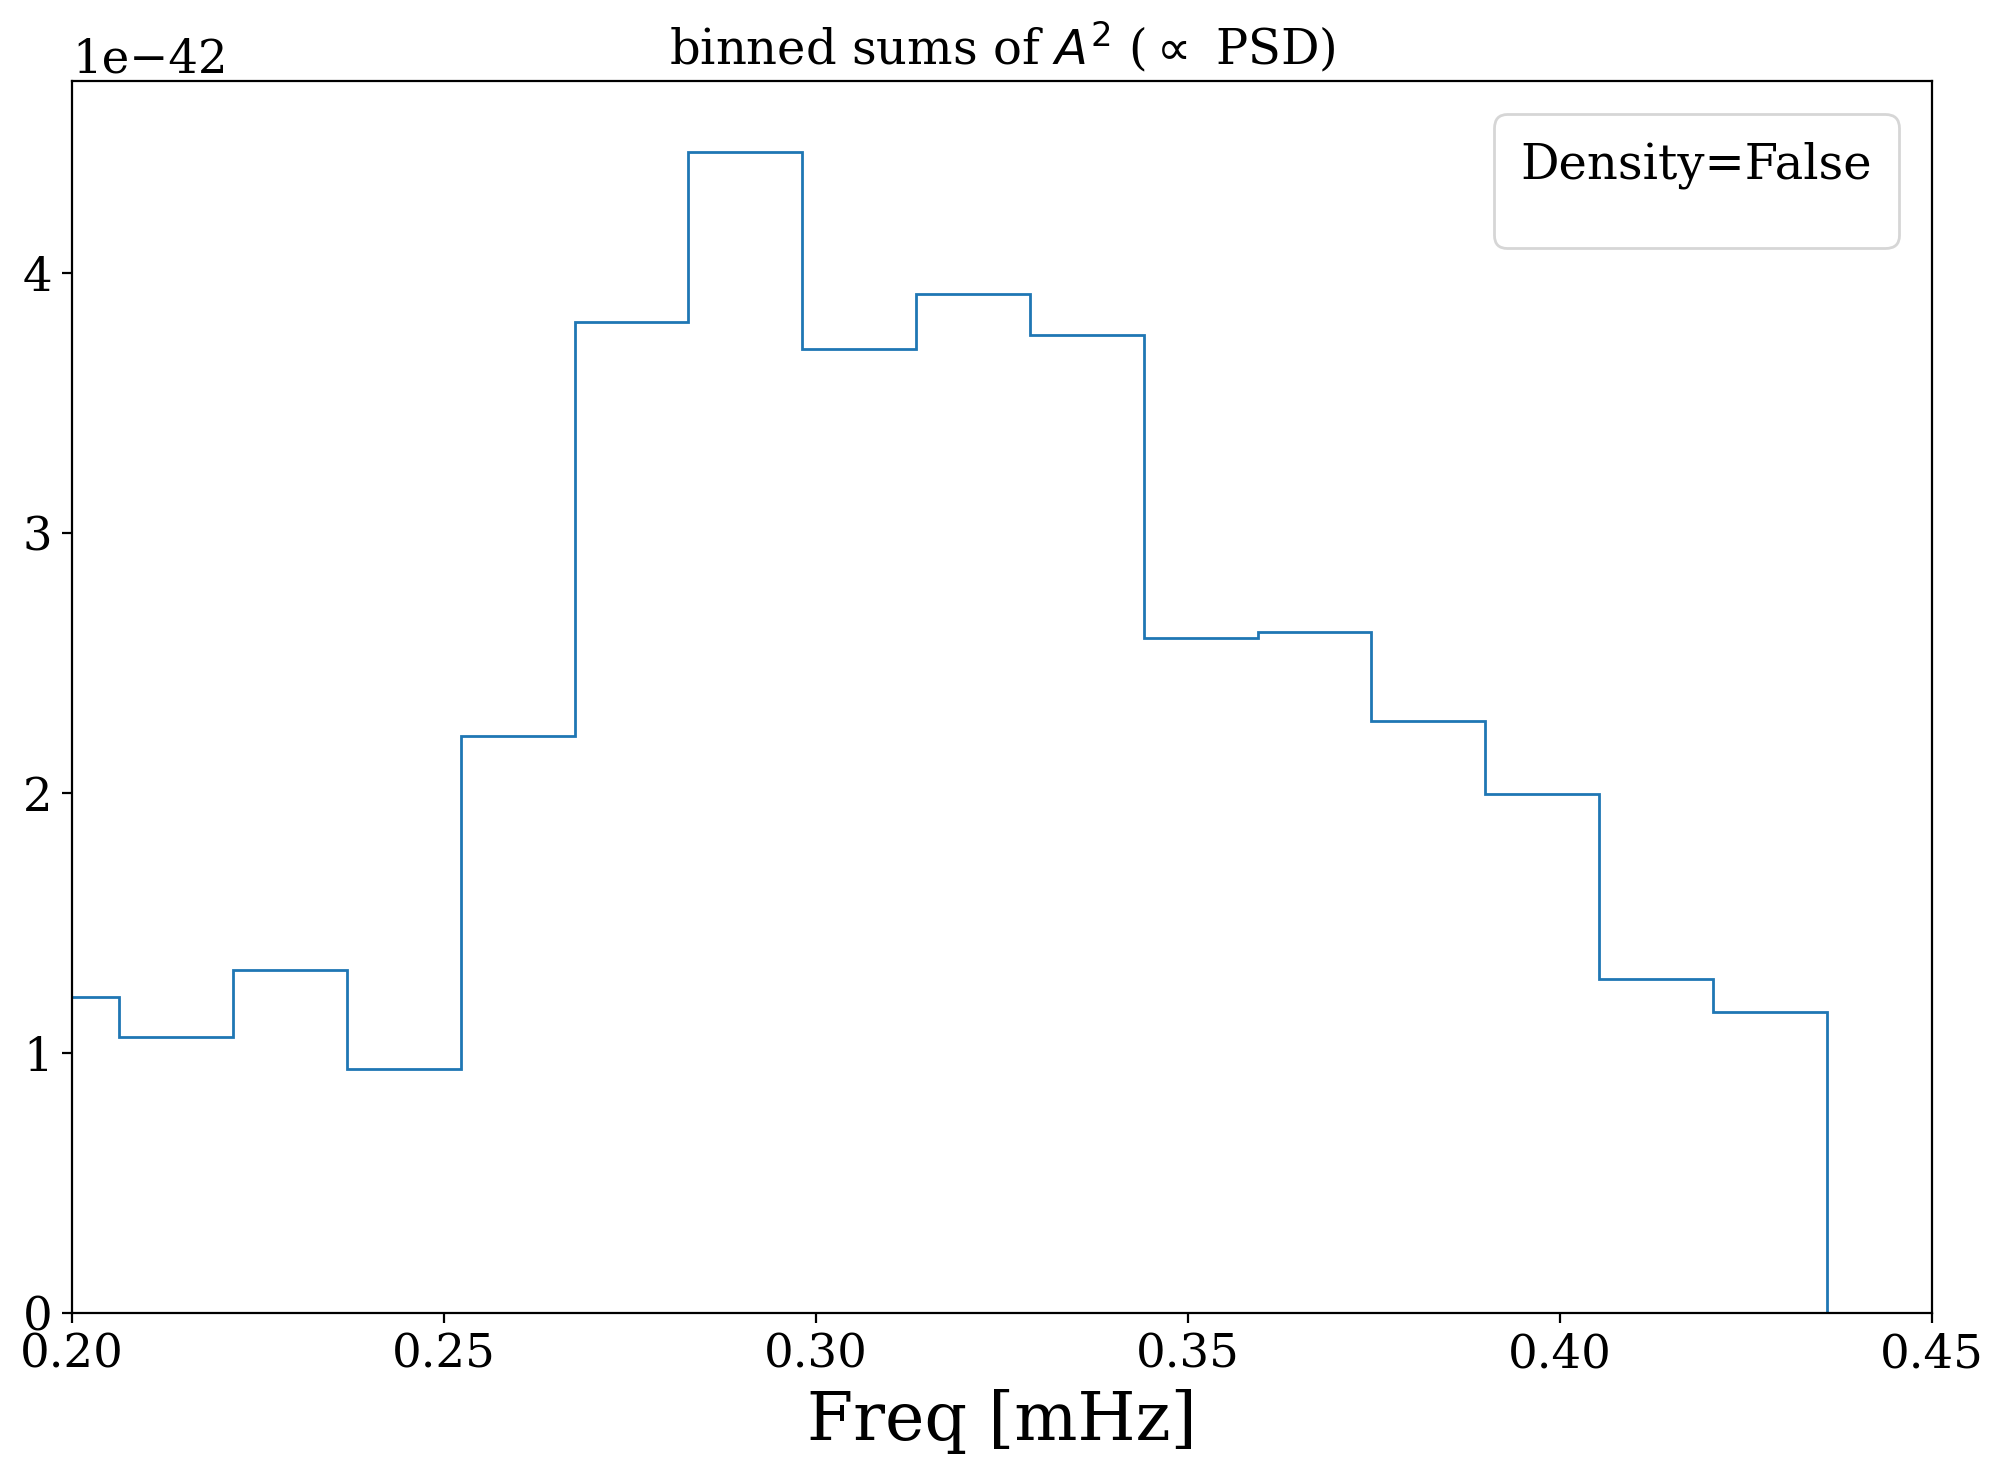

In [17]:
plt.hist(cv_df['f_gw[Hz]']*1e3, weights=cv_df['h']**2, bins=25, histtype='step', density=False, label='')
plt.xlabel('Freq [mHz]')
plt.title(r'binned sums of $A^2$ ($\propto$ PSD)', fontsize='xx-large')
plt.xlim(.2, 0.45)
plt.legend(title='Density=False', title_fontsize='xx-large')